In [1]:
from IPython.display import Image, display
import operator
from typing import Annotated, List, Literal, TypedDict
from langgraph.graph import END, START, StateGraph
from langgraph.types import Command, interrupt

#### Graph


In [2]:
class State(TypedDict):
  query: str
  route: str
  answer: str

In [3]:
def query_router(state: State):
    """Determine where the query should be routed."""

    query = state["query"].lower()

    if "temperature" in query or "weather" in query:
        route = "temperature"

    elif "latest" in query or "news" in query:
        route = "web"

    else:
        route = "general"

    print(f"\n[Router] Routing query to -> {route}")

    return {"route": route}


def temperature_node(state: State):
    """Mock Temperature Node"""

    print("[Temperature Node] Executing...")

    return {
        "answer": "The current temperature is 32°C."
    }


def general_qa_node(state: State):
    """Mock General Question Answering"""

    print("[General QA Node] Executing...")

    return {
        "answer": f"This is a general answer for: '{state['query']}'"
    }


def web_search_node(state: State):
    """Mock Web Search"""

    print("[Web Search Node] Executing...")

    return {
        "answer": f"Showing the latest web search results for: '{state['query']}'"
    }


def final_response(state: State):
    """Display the final answer."""

    print("\n========== FINAL RESPONSE ==========")
    print(state["answer"])
    print("====================================")

    return state



In [4]:
# -------------------------------
# Routing Function
# -------------------------------

def route_query(state: State):
    return state["route"]

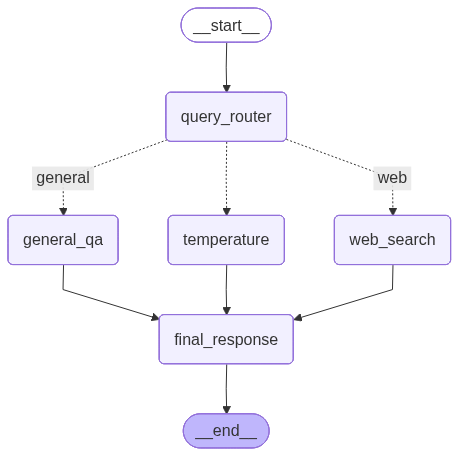

In [5]:
# Build the graph
builder = StateGraph(State)

# Add Nodes
builder.add_node("query_router", query_router)
builder.add_node("temperature", temperature_node)
builder.add_node("general_qa", general_qa_node)
builder.add_node("web_search", web_search_node)
builder.add_node("final_response", final_response)

# Add Starting Edge
builder.add_edge(START, "query_router")

# Add Conditional Edges
builder.add_conditional_edges(
    "query_router",
    route_query,
    {
        "temperature": "temperature",
        "general": "general_qa",
        "web": "web_search",
    },
)

# Connect all routes to the final response
builder.add_edge("temperature", "final_response")
builder.add_edge("general_qa", "final_response")
builder.add_edge("web_search", "final_response")

# End the graph
builder.add_edge("final_response", END)

# Compile
graph = builder.compile()
                 
display(Image(graph.get_graph().draw_mermaid_png()))

In [6]:
print("Welcome to the LangGraph AI Assistant!")
print("You can ask me:")
print("- General Questions")
print("- Temperature Queries")
print("- Latest News")
print("Type 'exit' to quit.\n")

while True:
    query = input("You: ")

    if query.lower() == "exit":
        print("Thank you for using the LangGraph AI Assistant. Goodbye!")
        break

    result = graph.invoke(
        {
            "query": query,
            "route": "",
            "answer": "",
        }
    )

    print(f"Assistant: {result['answer']}\n")

Welcome to the LangGraph AI Assistant!
You can ask me:
- General Questions
- Temperature Queries
- Latest News
Type 'exit' to quit.

Thank you for using the LangGraph AI Assistant. Goodbye!
